<a href="https://colab.research.google.com/github/Abhay-07082005/food-freshness-app/blob/main/food_freshness.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [27]:
!pip install tensorflow matplotlib

In [28]:
from google.colab import files
uploaded = files.upload()

Saving Mixed Qualit_Fruits.zip to Mixed Qualit_Fruits (1).zip
Saving Bad Quality_Fruits.zip to Bad Quality_Fruits.zip


In [29]:
import zipfile

zip_name = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_name, 'r') as zip_ref:
    zip_ref.extractall("/content/dataset")

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [31]:
import os

for root, dirs, files in os.walk("/content/dataset"):
    print(root)
    break

/content/dataset


In [32]:
import tensorflow as tf

DATASET_PATH = "/content/dataset"
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# IMPORTANT: SAVE CLASS NAMES HERE
class_names = train_ds.class_names
print("Classes:", class_names)

Found 1074 files belonging to 6 classes.
Using 860 files for training.
Found 1074 files belonging to 6 classes.
Using 214 files for validation.
Classes: ['Apple', 'Banana', 'Guava', 'Lemon', 'Orange', 'Pomegranate']


In [33]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)

In [34]:
from tensorflow.keras import layers

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
])

In [35]:
from tensorflow.keras import models

model = models.Sequential([
    layers.Rescaling(1./255, input_shape=(224,224,3)),

    data_augmentation,

    layers.Conv2D(32, 3, activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, activation='relu'),
    layers.MaxPooling2D(),

    layers.Dropout(0.3),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(len(class_names), activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [36]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_5 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,734 (42.61 MB)

 Trainable params: 11,169,734 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [37]:

EPOCHS = 15

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)



Epoch 1/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 123s 4s/step - accuracy: 0.2581 - loss: 1.9475 - val_accuracy: 0.4252 - val_loss: 1.6739
Epoch 2/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 108s 4s/step - accuracy: 0.3907 - loss: 1.4171 - val_accuracy: 0.4393 - val_loss: 1.2884
Epoch 3/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 106s 4s/step - accuracy: 0.6372 - loss: 0.9119 - val_accuracy: 0.6308 - val_loss: 0.8465
Epoch 4/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 146s 4s/step - accuracy: 0.7349 - loss: 0.6085 - val_accuracy: 0.7523 - val_loss: 0.5829
Epoch 5/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 106s 4s/step - accuracy: 0.7756 - loss: 0.5637 - val_accuracy: 0.7523 - val_loss: 0.5611
Epoch 6/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 123s 5s/step - accuracy: 0.8535 - loss: 0.3619 - val_accuracy: 0.7196 - val_loss: 0.6971
Epoch 7/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 106s 4s/step - accuracy: 0.8453 - loss: 0.3665 - val_accuracy: 0.8505 - val_loss: 0.4640
Epoch 8/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 146s 4s/step - accuracy: 0.8709 - loss: 0.3553 - val_accuracy: 0.8738 - v

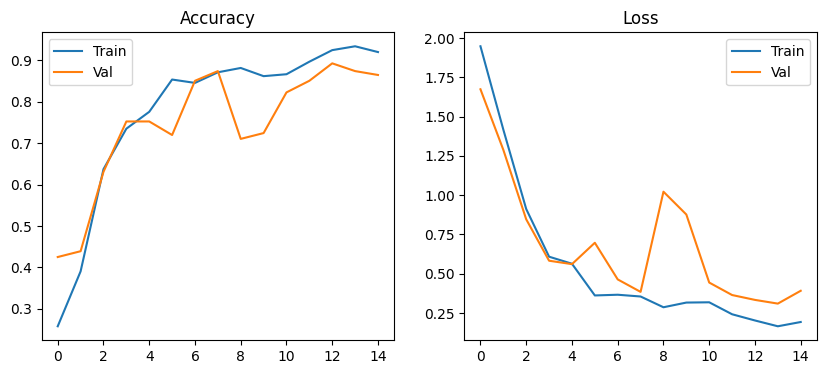

In [47]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title("Loss")
plt.legend()

plt.show()

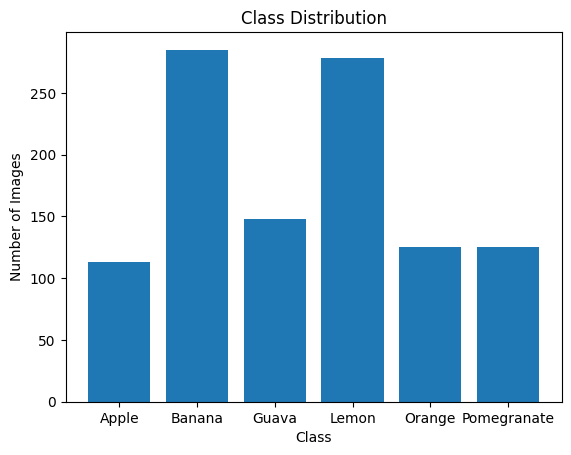

In [48]:
import os

class_counts = {}

for cls in class_names:
    path = os.path.join(DATASET_PATH, cls)
    class_counts[cls] = len(os.listdir(path))

plt.figure()
plt.bar(class_counts.keys(), class_counts.values())
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()

In [39]:
model.save("food_freshness_model.keras")
print("Model saved successfully!")

Model saved successfully!


In [40]:
import numpy as np
from tensorflow.keras.utils import load_img, img_to_array

def predict(img_path):
    img = load_img(img_path, target_size=(224,224))
    img = img_to_array(img)
    img = np.expand_dims(img, axis=0) / 255.0

    pred = model.predict(img)[0]

    index = np.argmax(pred)
    confidence = np.max(pred) * 100

    print("Prediction:", class_names[index])
    print("Confidence:", round(confidence, 2), "%")

    # RULE SYSTEM
    if confidence >= 70:
        print("🟢 GOOD (Fresh)")
    elif 50 <= confidence < 70:
        print("🟡 MODERATE")
    elif 30 <= confidence < 50:
        print("🔴 NOT GOOD")
    else:
        print("⚫ ROTTEN")

In [22]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)

In [23]:
import numpy as np
from tensorflow.keras.preprocessing import image

def predict(img_path):
    img = image.load_img(img_path, target_size=(224,224))
    img = image.img_to_array(img)
    img = np.expand_dims(img, axis=0) / 255.0

    pred = model.predict(img)[0]

    index = np.argmax(pred)
    confidence = np.max(pred) * 100

    print("Prediction:", class_names[index])
    print("Confidence:", confidence)

In [42]:
from google.colab import files
uploaded = files.upload()

Saving IMG20200728190301.jpg to IMG20200728190301.jpg


In [43]:
img_path = list(uploaded.keys())[0]
print("Image selected:", img_path)

Image selected: IMG20200728190301.jpg


In [44]:
predict(img_path)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step
Prediction: Pomegranate
Confidence: 84.89 %
🟢 GOOD (Fresh)
